## Task 4. Assignment: Audio Classification Using CNN
## Objective
- Build a CNN-based audio classification model using an open-source audio dataset. Train it twice:
    - Part A: without augmentation
    - Part B: with SpecAugment
- Compare both settings to study the impact of spectrogram augmentation on model performance and overfitting.
### Dataset
Choose one open-source dataset for audio classification.

### Part A : Audio Classification without Augmentation

Dataset used: [ESC-50](): A collection of 2000, 5 second environmental recording

In [1]:
# download and unzip the dataset
!wget https://github.com/karoldvl/ESC-50/archive/master.zip
!unzip -q master.zip

--2026-08-03 11:46:20--  https://github.com/karoldvl/ESC-50/archive/master.zip
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/karolpiczak/ESC-50/archive/master.zip [following]
--2026-08-03 11:46:20--  https://github.com/karolpiczak/ESC-50/archive/master.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/karolpiczak/ESC-50/zip/refs/heads/master [following]
--2026-08-03 11:46:20--  https://codeload.github.com/karolpiczak/ESC-50/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 140.82.113.9
Connecting to codeload.github.com (codeload.github.com)|140.82.113.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘master.zip’

master.zip              [ <=> 

In [ ]:
import pandas as pd
import librosa
import os

def explore_dataset(path):
  ''' path: esc50 root path'''
  ds = pd.read_csv(os.path.join(path, "meta/esc50.csv"))
  duration = 0.0
  avg_sr = 0.0
  sr = 0
  print("Dataset Name: ESC-20")
  print("Total Samples: ", len(ds))

  # no. of classes, samples per class
  print("No. of classes: ", len(ds['category'].unique()))
  print("No. of Samples per Class:\n", ds['category'].value_counts())

  # dataset duration
  for file in os.listdir(os.path.join(path, "audio")):
    y, sr = librosa.load(os.path.join(path, "audio", file))
    avg_sr += sr
    duration += librosa.get_duration(y=y, sr=sr)
  avg_sr /= len(os.listdir(os.path.join(path, "audio")))

  # print infered values
  print(f"Sample Rate (avg): {avg_sr} Hz")
  print(f"Duration of dataset: {duration} seconds")
  print("Most Frequent Class: ", ds['category'].value_counts().idxmax())
  print("Least Frequent Class: ", ds['category'].value_counts().idxmin())
  return ds
  # sample rate of dataset
ds_meta = explore_dataset('/content/ESC-50-master')

In [14]:
import numpy as np

class AudioProcessor:

  def __init__(self, sr=16000, n_mels=64, n_fft=1024, hop_length=512, target_duration=4.0) -> None:
    self.sr = sr
    self.n_mels = n_mels
    self.n_fft = n_fft
    self.hop_length = hop_length
    self.target_sample = int(sr * target_duration)

  def load_and_resample(self, path):
    y, _ = librosa.load(path, sr=self.sr, mono=True)
    return y

  def pad_or_truncate(self, y):
    # truncate
    if len(y) > self.target_sample:
      y = y[:self.target_sample]
    # pad
    elif len(y) < self.target_sample:
      y = np.pad(y, (0, self.target_sample - len(y)), mode='constant')
    return y

  def extract_mel_spectrum(self, y):
    return librosa.feature.melspectrogram(y=y, sr=self.sr, n_mels=self.n_mels, n_fft=self.n_fft, hop_length=self.hop_length)

  def process(self, path):
    '''path: ESC-50 Root Directory path'''
    result  = []
    # loop through the file
    for file in os.listdir(os.path.join(path, "audio")):

      y = self.load_and_resample(os.path.join(path, "audio", file))
      y = self.pad_or_truncate(y)
      # get mel-spectrum
      mel_spectrum = self.extract_mel_spectrum(y)

      result.append(mel_spectrum)

    return np.array(result)

In [15]:
audio_processor = AudioProcessor()

result = audio_processor.process('/content/ESC-50-master')

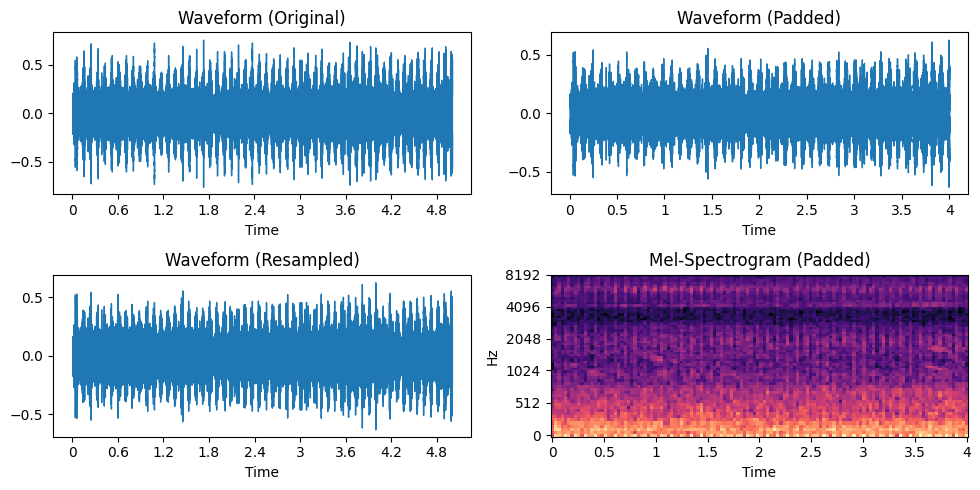

In [17]:
from librosa.core.constantq import audio
import matplotlib.pyplot as plt
import librosa.display as display
fig, ax = plt.subplots(2, 2, figsize=(10, 5))

# sample (helicoptor sound)
sample_path = "/content/ESC-50-master/audio/1-172649-C-40.wav"

# plot calculate the waveform
(y, sr), y_resampled = librosa.load(sample_path, sr=None), audio_processor.load_and_resample(sample_path)
display.waveshow(y=y, sr=sr, ax=ax[0][0])
ax[0][0].set_title("Waveform (Original)")

display.waveshow(y=y_resampled, sr=16000, ax=ax[1][0])
ax[1][0].set_title("Waveform (Resampled)")

y_padded = audio_processor.pad_or_truncate(y_resampled)
display.waveshow(y=y_padded, sr=16000, ax=ax[0][1])
ax[0][1].set_title("Waveform (Padded)")

mel_spectrum = audio_processor.extract_mel_spectrum(y_padded)
spectrum_db = librosa.power_to_db(mel_spectrum, ref=np.max)
display.specshow(spectrum_db, sr=16000, x_axis='time', y_axis='mel', ax=ax[1][1])
ax[1][1].set_title("Mel-Spectrogram (Padded)")

plt.tight_layout()
plt.show()


In [63]:
import torch
import torch.utils.data as data
class AudioDataset(data.Dataset):
  def __init__(self, file_list, labels, preprocessor, augment=None):
    self.file_list = file_list
    self.labels = labels
    self.preprocessor = preprocessor
  # None for PART A
    self.augment = augment

  def __getitem__(self, index):
    y = self.preprocessor.load_and_resample(self.file_list[index])
    y = self.preprocessor.pad_or_truncate(y)
    mel = self.preprocessor.extract_mel_spectrum(y)
    mel = librosa.power_to_db(mel, ref=np.max)
    mel_tensor = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
    if self.augment is not None:
      mel_tensor = self.augment(mel_tensor)
    label_tensor = torch.tensor(self.labels[index], dtype=torch.long)
    return mel_tensor, label_tensor

  def __len__(self):
    return len(self.file_list)

In [58]:
import torch.nn as nn
import torch.nn.functional as F

class AudioCNN(nn.Module):

  def __init__(self, num_classes):

    super(AudioCNN, self).__init__()

    self.feature = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            # regualizer
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1)))
    self.classification = nn.Sequential(
            nn.Flatten(),

            nn.Linear(64 * 1 * 1, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
    )

  def forward(self, x):
    x = self.feature(x)
    x = self.classification(x)
    return x

In [59]:
# data loader
audio_dir = '/content/ESC-50-master/audio/'
ds_meta['file_path'] = ds_meta['filename'].apply(lambda x: os.path.join(audio_dir, x))

# mapping
class_map = {name: idx for idx, name in enumerate(ds_meta['category'].unique())}
ds_meta['label'] = ds_meta['category'].map(class_map)

train_df = ds_meta[ds_meta['fold'] != 5]
val_df = ds_meta[ds_meta['fold'] == 5]

processor = AudioProcessor()

train_dataset = AudioDataset(train_df['file_path'].values, train_df['label'].values, processor)
val_dataset = AudioDataset(val_df['file_path'].values, val_df['label'].values, processor)

train_loader = data.DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = data.DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

In [60]:
import torch.optim as optim

def train_and_evaluate(model, train_loader, val_loader, epochs=30):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)
            _, preds = outputs.max(1)
            train_total += labels.size(0)
            train_correct += preds.eq(labels).sum().item()

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, preds = outputs.max(1)
                val_total += labels.size(0)
                val_correct += preds.eq(labels).sum().item()
        val_acc = 100. * val_correct / val_total
        scheduler.step(val_acc)
        # per epoch
        history['train_loss'].append(train_loss / train_total)
        history['val_loss'].append(val_loss / val_total)
        history['train_acc'].append(100. * train_correct / train_total)
        history['val_acc'].append(val_acc)
        current_lr = optimizer.param_groups[0]['lr']   # optional: print LR to confirm it's dropping
        print(f"Epoch {epoch+1:02d} | Train Acc: {history['train_acc'][-1]:.1f}% | Val Acc: {val_acc:.1f}% | LR: {current_lr:.6f}")

    return history

# Part A (Without Augmentation)
print("--- Starting Part A: No Augmentation ---")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_a = AudioCNN(num_classes=50).to(device)
history_a = train_and_evaluate(model_a, train_loader, val_loader, epochs=50)


--- Starting Part A: No Augmentation ---
Epoch 01 | Train Acc: 4.4% | Val Acc: 7.8% | LR: 0.001000
Epoch 02 | Train Acc: 9.2% | Val Acc: 14.8% | LR: 0.001000
Epoch 03 | Train Acc: 14.4% | Val Acc: 18.2% | LR: 0.001000
Epoch 04 | Train Acc: 18.1% | Val Acc: 20.2% | LR: 0.001000
Epoch 05 | Train Acc: 18.3% | Val Acc: 21.8% | LR: 0.001000
Epoch 06 | Train Acc: 19.5% | Val Acc: 18.5% | LR: 0.001000
Epoch 07 | Train Acc: 20.6% | Val Acc: 22.0% | LR: 0.001000
Epoch 08 | Train Acc: 23.6% | Val Acc: 25.2% | LR: 0.001000
Epoch 09 | Train Acc: 24.1% | Val Acc: 20.5% | LR: 0.001000
Epoch 10 | Train Acc: 24.7% | Val Acc: 22.2% | LR: 0.001000
Epoch 11 | Train Acc: 24.6% | Val Acc: 24.8% | LR: 0.001000
Epoch 12 | Train Acc: 25.8% | Val Acc: 25.5% | LR: 0.001000
Epoch 13 | Train Acc: 29.8% | Val Acc: 22.8% | LR: 0.001000
Epoch 14 | Train Acc: 28.2% | Val Acc: 27.2% | LR: 0.001000
Epoch 15 | Train Acc: 29.0% | Val Acc: 28.5% | LR: 0.001000
Epoch 16 | Train Acc: 32.0% | Val Acc: 23.5% | LR: 0.001000
Ep

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                  precision    recall  f1-score   support

             dog       0.13      0.38      0.19         8
  chirping_birds       0.43      0.38      0.40         8
  vacuum_cleaner       0.60      0.75      0.67         8
    thunderstorm       0.67      1.00      0.80         8
 door_wood_knock       0.83      0.62      0.71         8
     can_opening       0.00      0.00      0.00         8
            crow       0.33      0.62      0.43         8
        clapping       0.25      0.12      0.17         8
       fireworks       0.00      0.00      0.00         8
        chainsaw       0.38      0.38      0.38         8
        airplane       0.29      0.25      0.27         8
     mouse_click       0.75      0.38      0.50         8
   pouring_water       0.88      0.88      0.88         8
           train       0.41      0.88      0.56         8
           sheep       0.25      0.12      0.17         8
     water_drops       0.25      0.12      0.17         8
    church_be

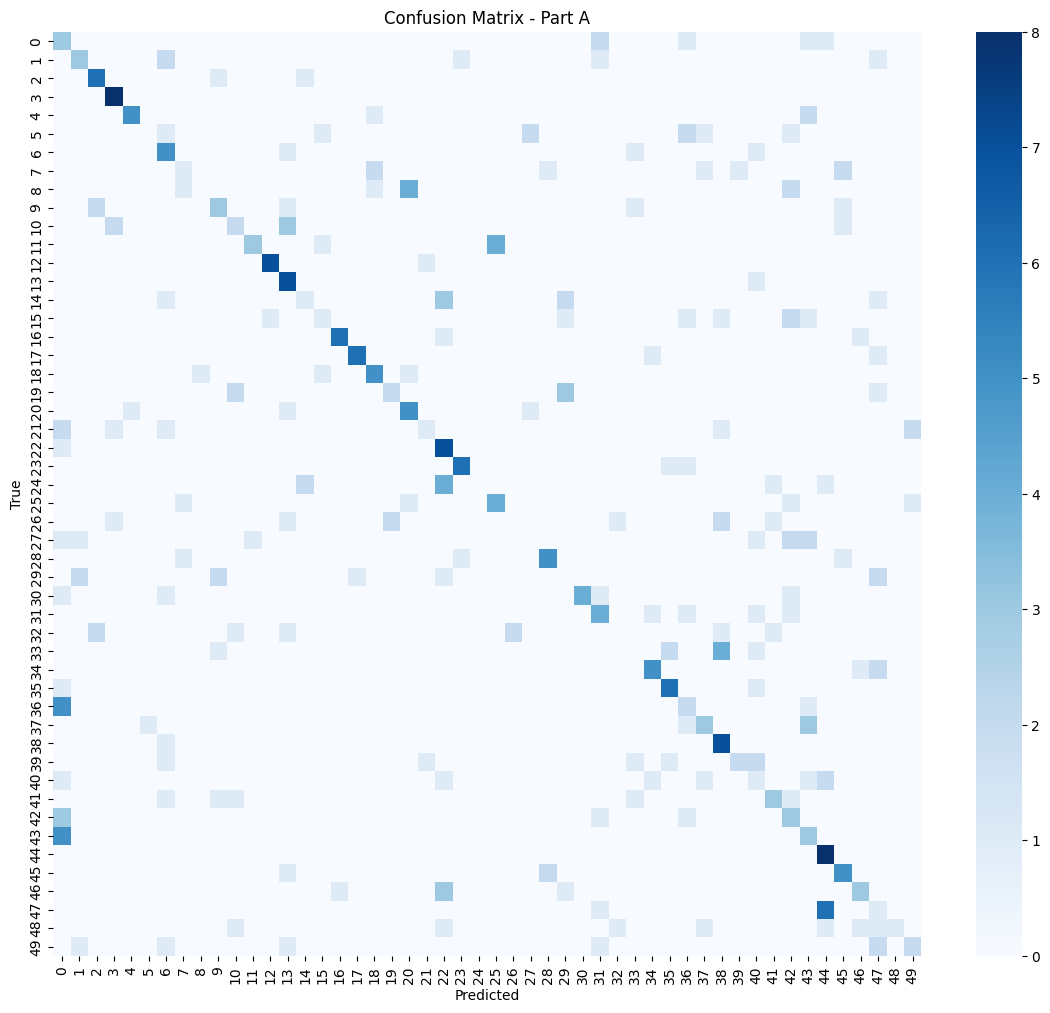

In [61]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return all_labels, all_preds

y_true, y_pred = get_predictions(model_a, val_loader)
print(classification_report(y_true, y_pred, target_names=list(class_map.keys())))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap='Blues')
plt.title("Confusion Matrix - Part A")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

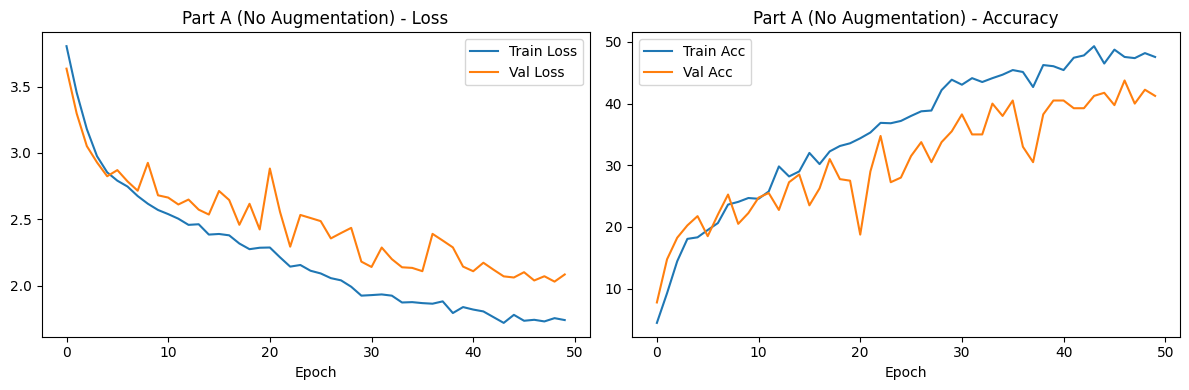

In [62]:
def plot_curves(history, title="Part A"):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    ax[0].plot(history['train_loss'], label='Train Loss')
    ax[0].plot(history['val_loss'], label='Val Loss')
    ax[0].set_title(f'{title} - Loss')
    ax[0].set_xlabel('Epoch')
    ax[0].legend()

    ax[1].plot(history['train_acc'], label='Train Acc')
    ax[1].plot(history['val_acc'], label='Val Acc')
    ax[1].set_title(f'{title} - Accuracy')
    ax[1].set_xlabel('Epoch')
    ax[1].legend()

    plt.tight_layout()
    plt.show()

plot_curves(history_a, "Part A (No Augmentation)")

In [65]:
import random

class SpecAugment:
    def __init__(self, freq_mask_param=8, time_mask_param=12):
        self.freq_mask_param = freq_mask_param
        self.time_mask_param = time_mask_param

    def frequency_mask(self, spec):
        spec = spec.clone()
        _, num_mels, num_frames = spec.shape
        f = random.randint(0, self.freq_mask_param)
        f0 = random.randint(0, max(0, num_mels - f))
        spec[:, f0:f0+f, :] = 0
        return spec

    def time_mask(self, spec):
        spec = spec.clone()
        _, num_mels, num_frames = spec.shape
        t = random.randint(0, self.time_mask_param)
        t0 = random.randint(0, max(0, num_frames - t))
        spec[:, :, t0:t0+t] = 0
        return spec

    def __call__(self, spec):
        spec = self.frequency_mask(spec)
        spec = self.time_mask(spec)
        return spec

In [66]:
augment = SpecAugment(freq_mask_param=8, time_mask_param=12)

train_dataset_aug = AudioDataset(train_df['file_path'].values, train_df['label'].values, processor, augment=augment)
train_loader_aug = data.DataLoader(train_dataset_aug, batch_size=32, shuffle=True, num_workers=2)

In [68]:
model_b = AudioCNN(num_classes=50).to(device)
history_b = train_and_evaluate(model_b, train_loader_aug, val_loader, epochs=50)

Epoch 01 | Train Acc: 3.9% | Val Acc: 7.0% | LR: 0.001000
Epoch 02 | Train Acc: 5.0% | Val Acc: 8.5% | LR: 0.001000
Epoch 03 | Train Acc: 8.1% | Val Acc: 9.5% | LR: 0.001000
Epoch 04 | Train Acc: 9.4% | Val Acc: 13.2% | LR: 0.001000
Epoch 05 | Train Acc: 10.6% | Val Acc: 16.2% | LR: 0.001000
Epoch 06 | Train Acc: 13.5% | Val Acc: 12.8% | LR: 0.001000
Epoch 07 | Train Acc: 16.1% | Val Acc: 16.5% | LR: 0.001000
Epoch 08 | Train Acc: 16.8% | Val Acc: 22.5% | LR: 0.001000
Epoch 09 | Train Acc: 17.5% | Val Acc: 12.5% | LR: 0.001000
Epoch 10 | Train Acc: 20.8% | Val Acc: 14.8% | LR: 0.001000
Epoch 11 | Train Acc: 19.7% | Val Acc: 21.2% | LR: 0.001000
Epoch 12 | Train Acc: 22.4% | Val Acc: 20.0% | LR: 0.001000
Epoch 13 | Train Acc: 21.0% | Val Acc: 21.5% | LR: 0.001000
Epoch 14 | Train Acc: 22.3% | Val Acc: 16.5% | LR: 0.000500
Epoch 15 | Train Acc: 23.4% | Val Acc: 27.8% | LR: 0.000500
Epoch 16 | Train Acc: 25.0% | Val Acc: 19.2% | LR: 0.000500
Epoch 17 | Train Acc: 25.3% | Val Acc: 22.5% | 

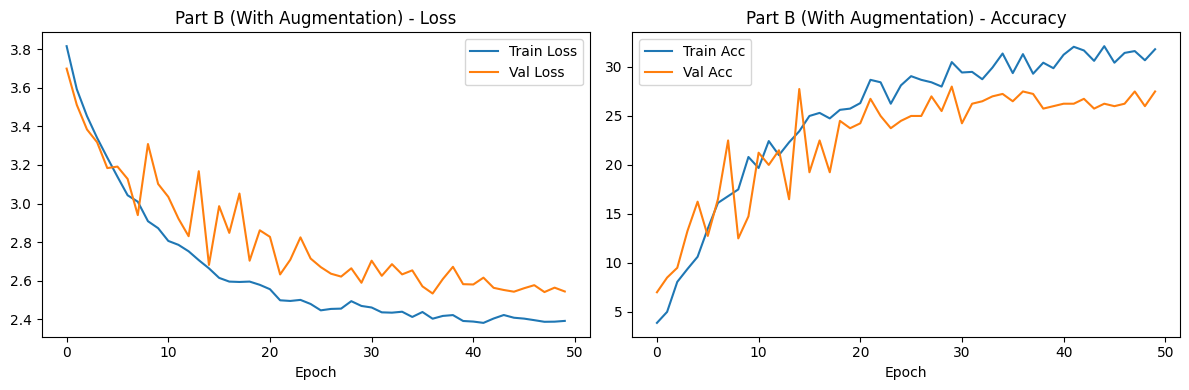

In [69]:
plot_curves(history_b, "Part B (With Augmentation)")

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                  precision    recall  f1-score   support

             dog       0.22      0.25      0.24         8
  chirping_birds       0.20      0.12      0.15         8
  vacuum_cleaner       0.50      0.75      0.60         8
    thunderstorm       0.30      0.88      0.45         8
 door_wood_knock       0.62      0.62      0.62         8
     can_opening       1.00      0.12      0.22         8
            crow       0.00      0.00      0.00         8
        clapping       0.00      0.00      0.00         8
       fireworks       0.00      0.00      0.00         8
        chainsaw       0.21      0.38      0.27         8
        airplane       0.36      0.50      0.42         8
     mouse_click       1.00      0.12      0.22         8
   pouring_water       1.00      0.25      0.40         8
           train       0.38      0.38      0.38         8
           sheep       0.60      0.38      0.46         8
     water_drops       0.00      0.00      0.00         8
    church_be

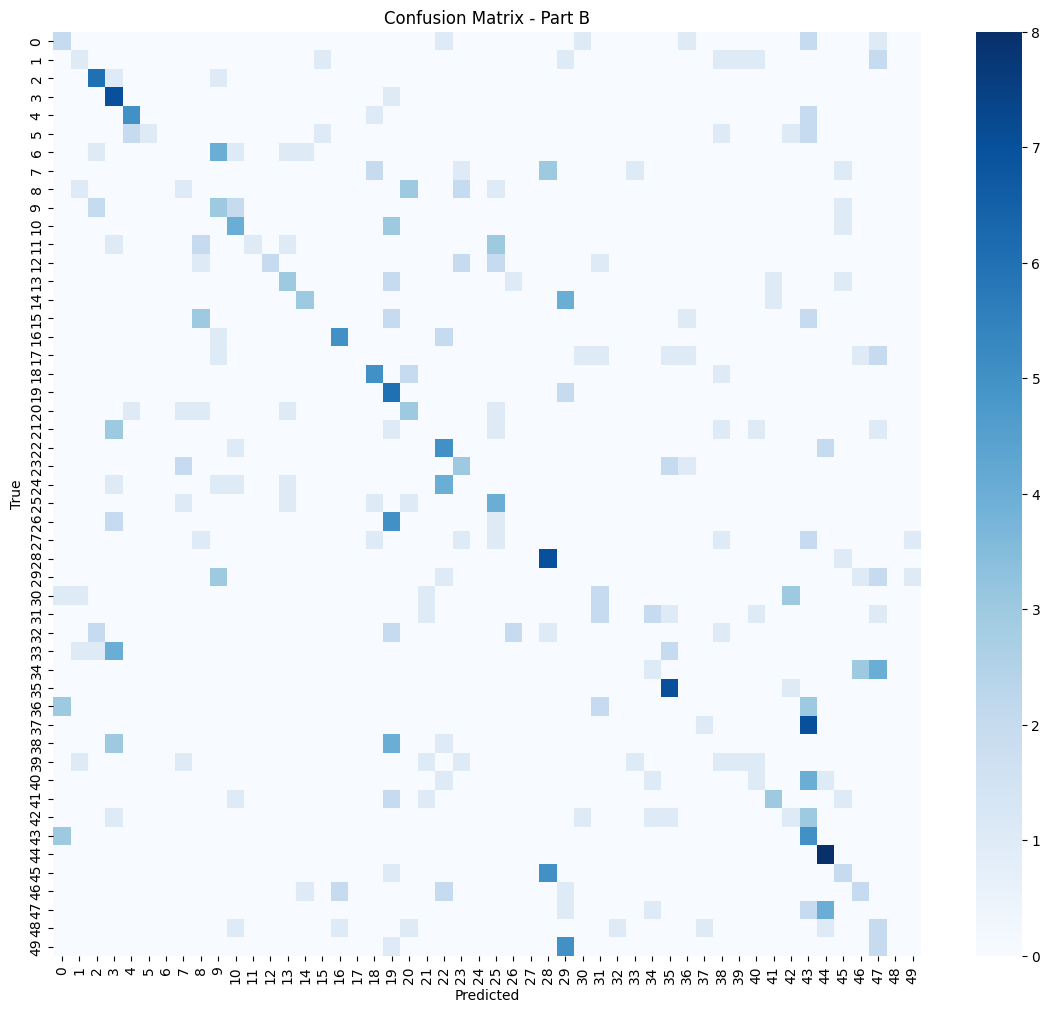

In [71]:
y_true, y_pred = get_predictions(model_b, val_loader)
print(classification_report(y_true, y_pred, target_names=list(class_map.keys())))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap='Blues')
plt.title("Confusion Matrix - Part B")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [72]:
torch.save(model_a.state_dict(), 'model_a_no_augment.pth')
torch.save(model_b.state_dict(), 'model_b_specaugment.pth')

In [73]:
idx_to_class = {v: k for k, v in class_map.items()}

In [78]:
import random

def get_correct_incorrect(model, dataset, n=3):
    model.eval()
    all_correct = []
    all_incorrect = []
    with torch.no_grad():
        for i in range(len(dataset)):
            spec, label = dataset[i]
            pred = model(spec.unsqueeze(0).to(device))
            pred = torch.argmax(pred).item()
            label = label.item()

            if pred == label:
                all_correct.append((spec, label, pred))
            else:
                all_incorrect.append((spec, label, pred))

    # Randomly sample 'n' from all_correct and all_incorrect
    correct_samples = random.sample(all_correct, min(n, len(all_correct)))
    incorrect_samples = random.sample(all_incorrect, min(n, len(all_incorrect)))

    return correct_samples, incorrect_samples

In [75]:
def plot_predictions(samples, title):
    plt.figure(figsize=(15, 4))
    for i, (spec, label, pred) in enumerate(samples):
        plt.subplot(1, len(samples), i+1)
        plt.imshow(spec.squeeze(), aspect="auto", origin="lower")
        plt.title(f"True: {idx_to_class[label]}\nPred: {idx_to_class[pred]}")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

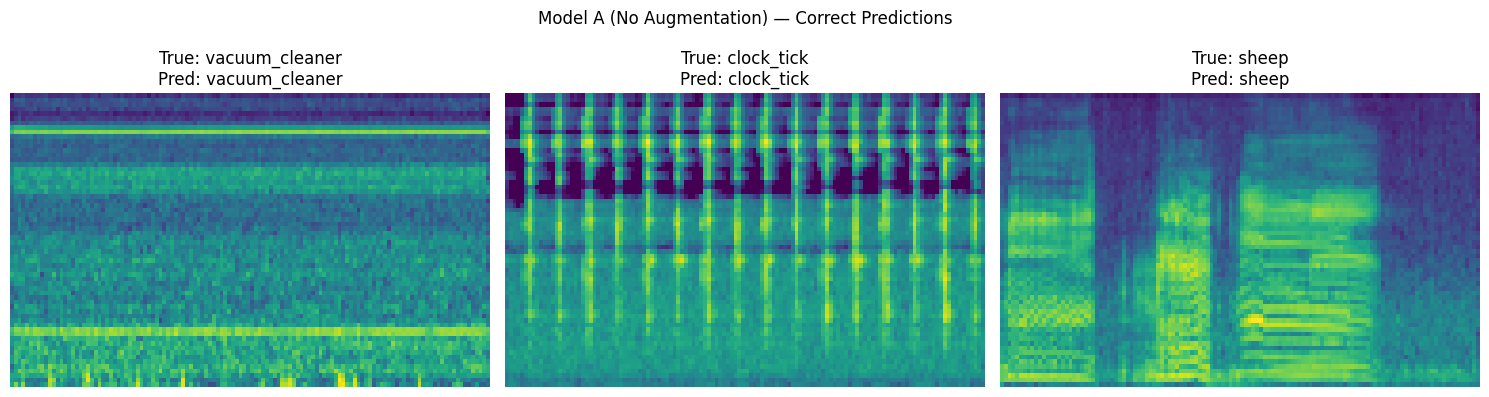

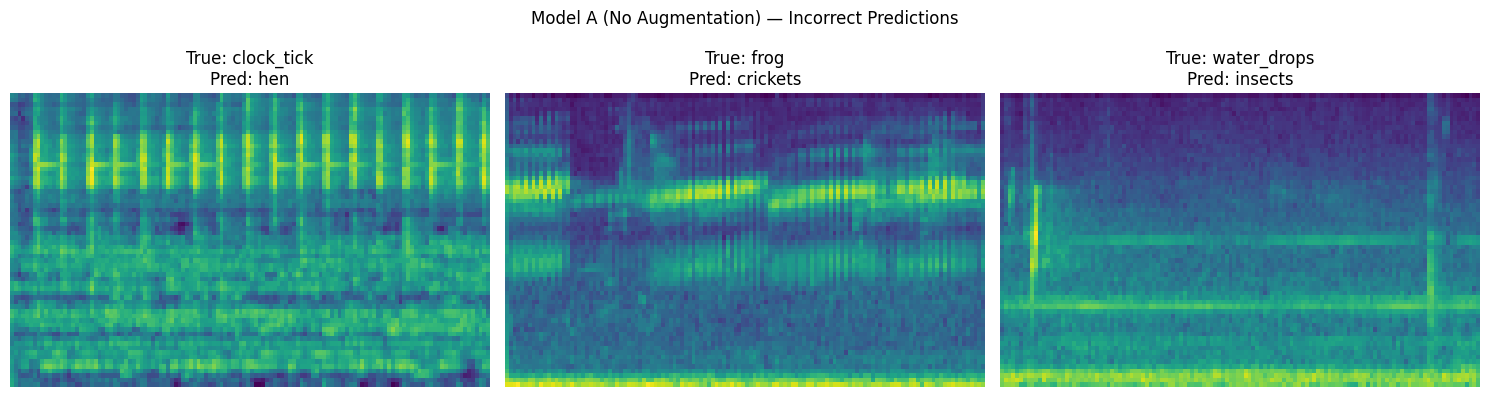

In [79]:
correct_a, incorrect_a = get_correct_incorrect(model_a, val_dataset, n=3)
plot_predictions(correct_a, "Model A (No Augmentation) — Correct Predictions")
plot_predictions(incorrect_a, "Model A (No Augmentation) — Incorrect Predictions")

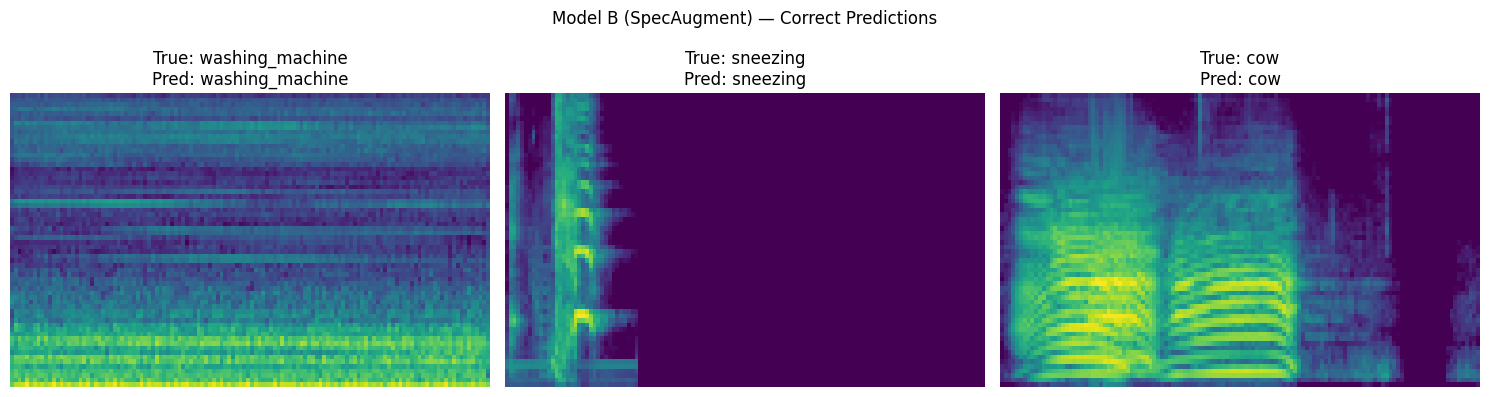

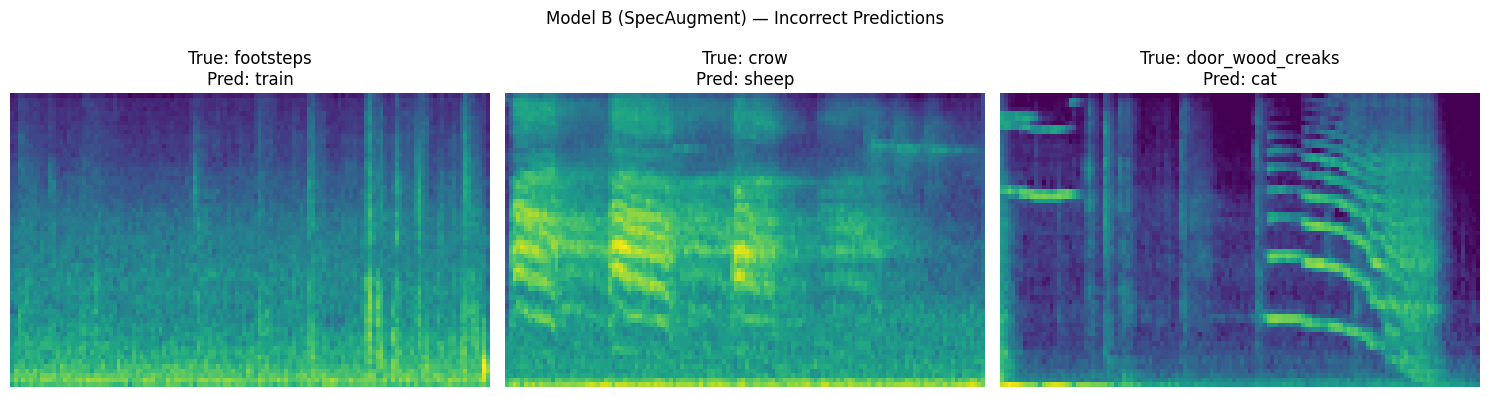

In [80]:
correct_b, incorrect_b = get_correct_incorrect(model_b, val_dataset, n=3)
plot_predictions(correct_b, "Model B (SpecAugment) — Correct Predictions")
plot_predictions(incorrect_b, "Model B (SpecAugment) — Incorrect Predictions")

In [81]:
def predict_single(model, file_path, processor):
    model.eval()
    y = processor.load_and_resample(file_path)
    y = processor.pad_or_truncate(y)
    mel = processor.extract_mel_spectrum(y)
    mel = librosa.power_to_db(mel, ref=np.max)   # skip if you didn't add log-scaling
    spec = torch.tensor(mel, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(spec)
        pred_idx = torch.argmax(output, dim=1).item()
        confidence = torch.softmax(output, dim=1)[0][pred_idx].item()

    print(f"Predicted class: {idx_to_class[pred_idx]} (confidence: {confidence*100:.1f}%)")
    return idx_to_class[pred_idx], confidence

# Thunder storm audio
predict_single(model_a, '/content/ESC-50-master/audio/1-101296-B-19.wav', processor)

Predicted class: snoring (confidence: 24.5%)


('snoring', 0.24473464488983154)

In [84]:
predict_single(model_a, "/content/ESC-50-master/audio/1-115920-A-22.wav", processor)

Predicted class: clapping (confidence: 65.6%)


('clapping', 0.6556739211082458)

In [83]:
predict_single(model_b, '/content/ESC-50-master/audio/1-101296-B-19.wav', processor)

Predicted class: thunderstorm (confidence: 24.9%)


('thunderstorm', 0.24932003021240234)

In [85]:
predict_single(model_b, "/content/ESC-50-master/audio/1-115920-A-22.wav", processor)

Predicted class: clapping (confidence: 50.0%)


('clapping', 0.5001024603843689)

### Observation

### Comparision Table:
| Type | Train Acc | Val Acc | Gap | Overall Acc | Macro F1 |
|---|---|---|---|---|---|
| Part A (No Aug) | 47.6% | 41.2% | 6.4 | 41% | 0.38 |
| Part B (SpecAugment) | 31.8% | 27.5% | 4.3 | 28% | 0.23 |

### 1. Did SpecAugment improve generalization?

No. Overall val accuracy dropped from 41% to 28%, and macro F1 dropped from 0.38 to 0.23 — a large decline, not an improvement.

### 2. Was overfitting reduced?

Although the train-validation gap decreased (6.4% → 4.3%), this is not a true improvement. The gap became smaller because the training accuracy dropped significantly (47.6% → 31.8%), indicating underfitting rather than reduced overfitting.

### 3. Which classes improved or worsened?

Only 7 classes improved (by F1): `dog`, `can_opening`, `airplane`, `sheep`, `pig`, `washing_machine`, `rooster`.

Roughly 35+ classes got worse, several dropping straight to F1 = 0.00 in Part B where they weren't zero in Part A: `crow`, `clapping`, `water_drops`, `clock_alarm`, `frog`, `laughing`, `coughing`, `snoring`, `cat`, `door_wood_creaks`, `crickets`. Some of your best-performing Part A classes (`pouring_water` 0.88→0.40, `clock_alarm` 0.80→0.00, `crying_baby` 0.62→0.14, `brushing_teeth` 0.75→0.33) took the biggest hits — these look like classes with distinctive, localized spectral signatures (single sharp bursts, specific frequency bands) that time/frequency masking likely destroyed.

### 4. Key observations

- Part B has far more classes at 0 precision/recall/F1 than Part A (11 zero-classes vs 8), meaning the model is defaulting to confidently predicting a smaller subset of "safe" classes and never predicting several categories at all — a classic underfitting/collapse pattern, not a healthy generalization pattern.

- Classes that survived masking well tend to have broad, sustained spectral energy across time (`rain`, `wind`, `vacuum_cleaner`, `hand_saw`) — masking a chunk of a continuous, repetitive sound doesn't destroy its identity.

- Classes that collapsed tend to be short, transient, or single-event sounds (`clock_alarm`, `snoring`, `crying_baby`, `pouring_water`) — SpecAugment's random time/frequency masks can wipe out the one distinguishing burst in a 4-second clip, especially since ESC-50 sounds are more varied/localized than continuous speech.